# 02 — Exploratory Data Analysis (EDA)

**Objective**: Explore the silver-layer data to understand distributions, relationships, missing patterns, and correlations with the target variable (`TARGET`: 1 = default, 0 = no default).

## Data Source

| Table | Location | Rows | Cols |
|-------|----------|------|------|
| `application_train` | `data/processed/` | 307,511 | 124 |
| `bureau` | `data/processed/` | 1,716,428 | 17 |

Default rate: **8.07%** (class imbalance ~1:11)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Project paths
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"  # Silver layer
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Silver layer: {PROCESSED_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Silver layer: /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/data/processed
Figures dir:  /home/felipefrl/Documents/Coding/JupyterNotebooks/credit-risk-mlplatform/figures


In [2]:
# Load main application table from silver layer
df = pd.read_parquet(PROCESSED_DIR / "application_train.parquet")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn dtypes:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"  {str(dtype):20s} {count:>3} columns")

df.head(3)

Shape: 307,511 rows × 124 columns
Memory: 102.7 MB

Column dtypes:
  float32               66 columns
  int8                  38 columns
  category               2 columns
  int16                  2 columns
  category               1 columns
  category               1 columns
  int32                  1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  float64                1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  category               1 columns
  category               1 columns


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,DAYS_EMPLOYED_ANOMALY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.902807,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.900070,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.145107,0


## 2. Target Distribution

Target distribution:
  No default (0):    282,686  (91.93%)
  Default    (1):     24,825  (8.07%)

  Default rate:     8.07%
  Imbalance ratio:  1:11 (non-default : default)


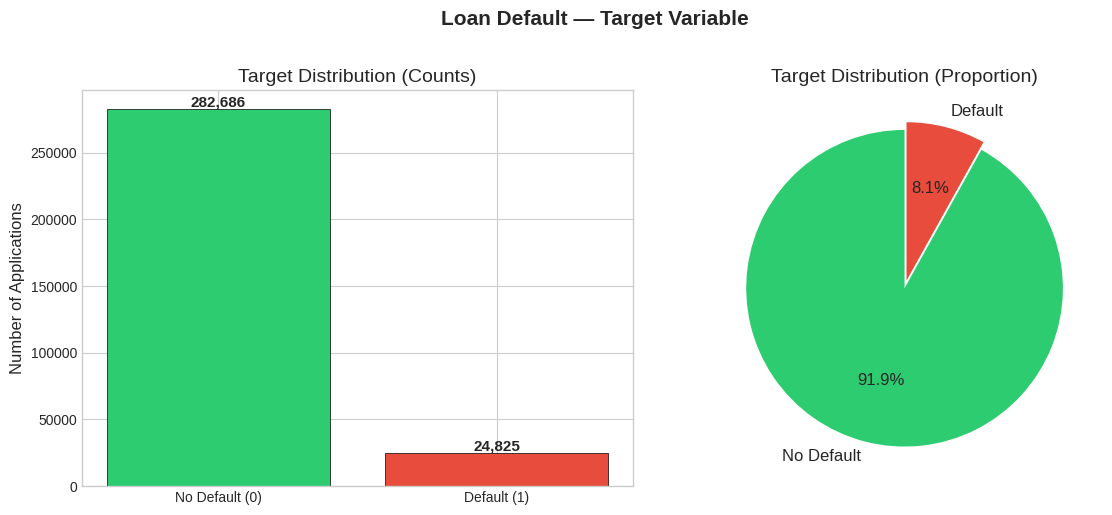

In [3]:
target_counts = df["TARGET"].value_counts().sort_index()
default_rate = df["TARGET"].mean()

print("Target distribution:")
print(f"  No default (0): {target_counts[0]:>10,}  ({(1 - default_rate)*100:.2f}%)")
print(f"  Default    (1): {target_counts[1]:>10,}  ({default_rate*100:.2f}%)")
print(f"\n  Default rate:     {default_rate*100:.2f}%")
print(f"  Imbalance ratio:  1:{int((1 - default_rate) / default_rate)} (non-default : default)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["No Default (0)", "Default (1)"], target_counts.values, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Target Distribution (Counts)")
axes[0].set_ylabel("Number of Applications")
for i, (val, count) in enumerate(zip(["0", "1"], target_counts.values)):
    axes[0].text(i, count + 2000, f"{count:,}", ha="center", fontweight="bold", fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=["No Default", "Default"], autopct="%1.1f%%",
            colors=colors, startangle=90, explode=(0, 0.05), textprops={"fontsize": 12})
axes[1].set_title("Target Distribution (Proportion)")

fig.suptitle("Loan Default — Target Variable", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Numeric Features Analysis

In [4]:
# Key numeric features to analyze
numeric_features = {
    "AMT_INCOME_TOTAL": {"clip_upper": 500_000, "label": "Total Income"},
    "AMT_CREDIT": {"clip_upper": 2_000_000, "label": "Credit Amount"},
    "AMT_ANNUITY": {"clip_upper": 80_000, "label": "Annuity Amount"},
    "AMT_GOODS_PRICE": {"clip_upper": 2_000_000, "label": "Goods Price"},
    "AGE_YEARS": {"clip_upper": None, "label": "Age (Years)"},
    "DAYS_EMPLOYED": {"clip_upper": None, "label": "Days Employed (negative = before application)"},
}

# Print summary stats for these features
print("Key numeric features — summary statistics:\n")
summary = df[list(numeric_features.keys())].describe().round(1)
display(summary)

Key numeric features — summary statistics:



,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AGE_YEARS,DAYS_EMPLOYED
count,307511.0,307511.0,307499.0,307233.0,307511.0,252137.0
mean,168797.9,599026.0,27108.6,538396.2,43.9,-2384.2
std,237123.1,402490.8,14493.7,369446.5,11.9,2338.4
min,25650.0,45000.0,1615.5,40500.0,20.5,-17912.0
25%,112500.0,270000.0,16524.0,238500.0,34.0,-3175.0
50%,147150.0,513531.0,24903.0,450000.0,43.1,-1648.0
75%,202500.0,808650.0,34596.0,679500.0,53.9,-767.0
max,117000000.0,4050000.0,258025.5,4050000.0,69.1,0.0


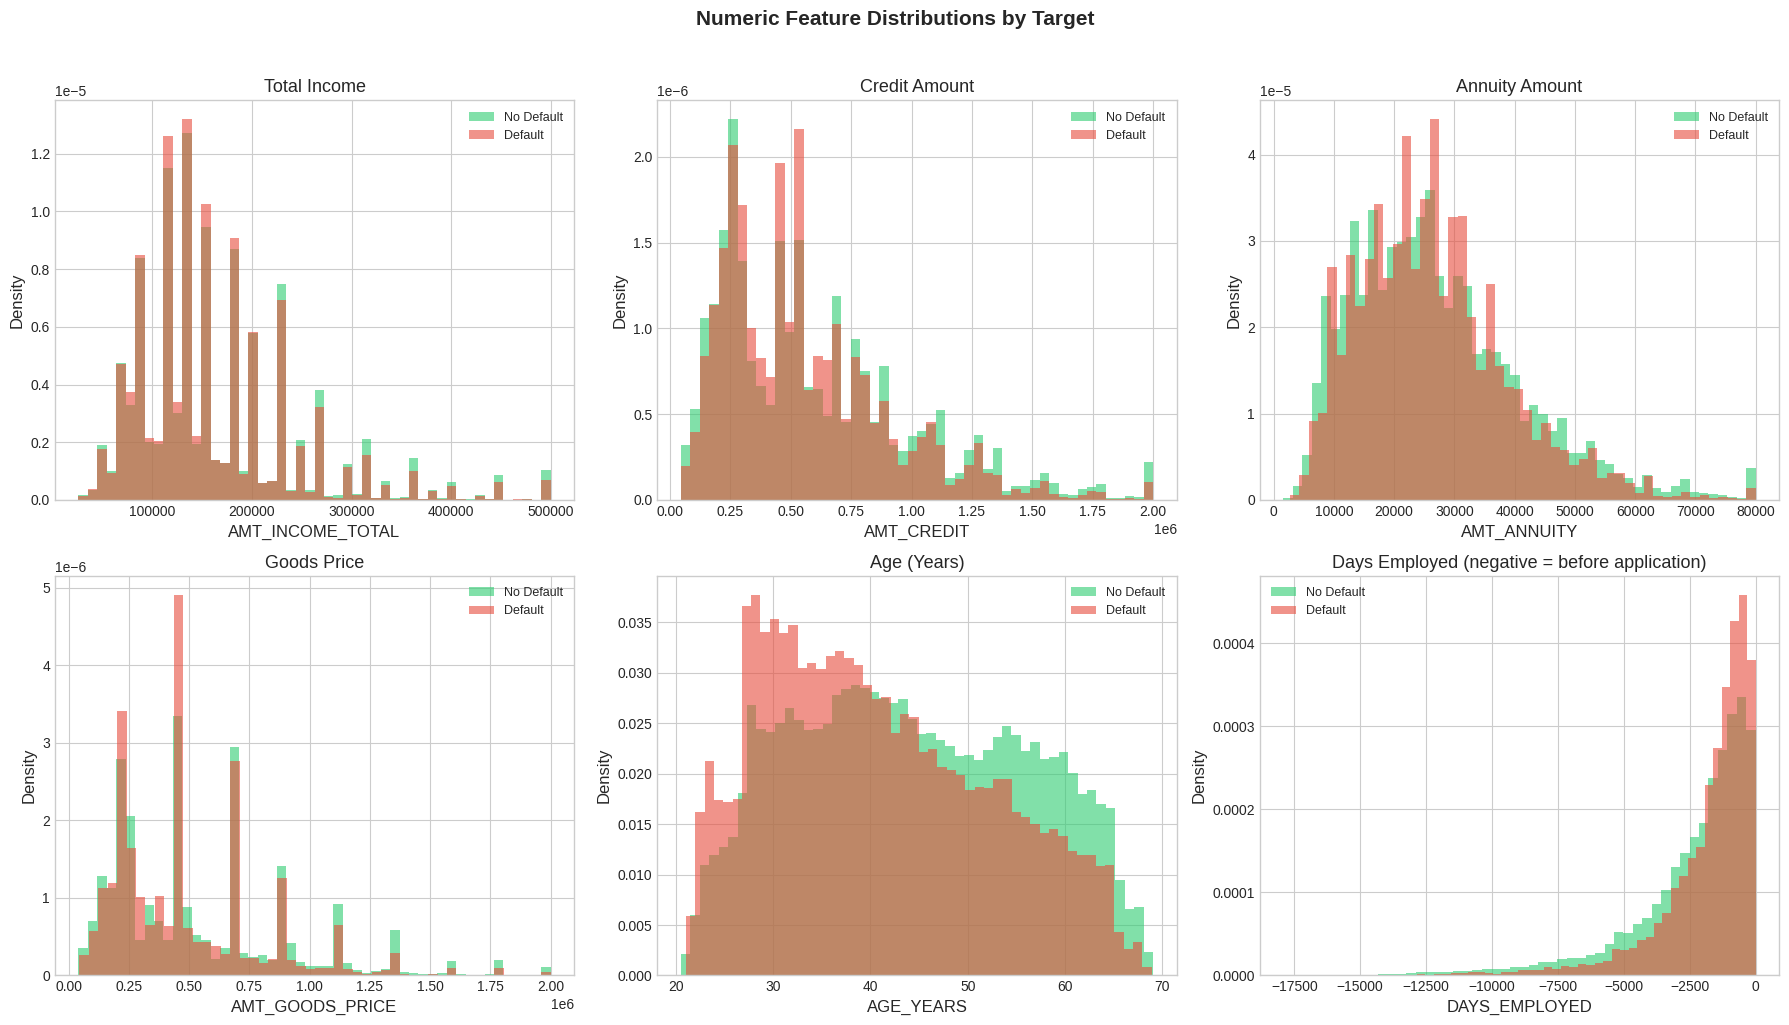

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (feat, config) in enumerate(numeric_features.items()):
    ax = axes[idx]
    
    # Separate by target
    data_0 = df.loc[df["TARGET"] == 0, feat].dropna()
    data_1 = df.loc[df["TARGET"] == 1, feat].dropna()
    
    # Clip outliers for visualization
    if config["clip_upper"] is not None:
        data_0 = data_0.clip(upper=config["clip_upper"])
        data_1 = data_1.clip(upper=config["clip_upper"])
    
    ax.hist(data_0, bins=50, alpha=0.6, label="No Default", color="#2ecc71", density=True)
    ax.hist(data_1, bins=50, alpha=0.6, label="Default", color="#e74c3c", density=True)
    ax.set_title(config["label"], fontsize=13)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

fig.suptitle("Numeric Feature Distributions by Target", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

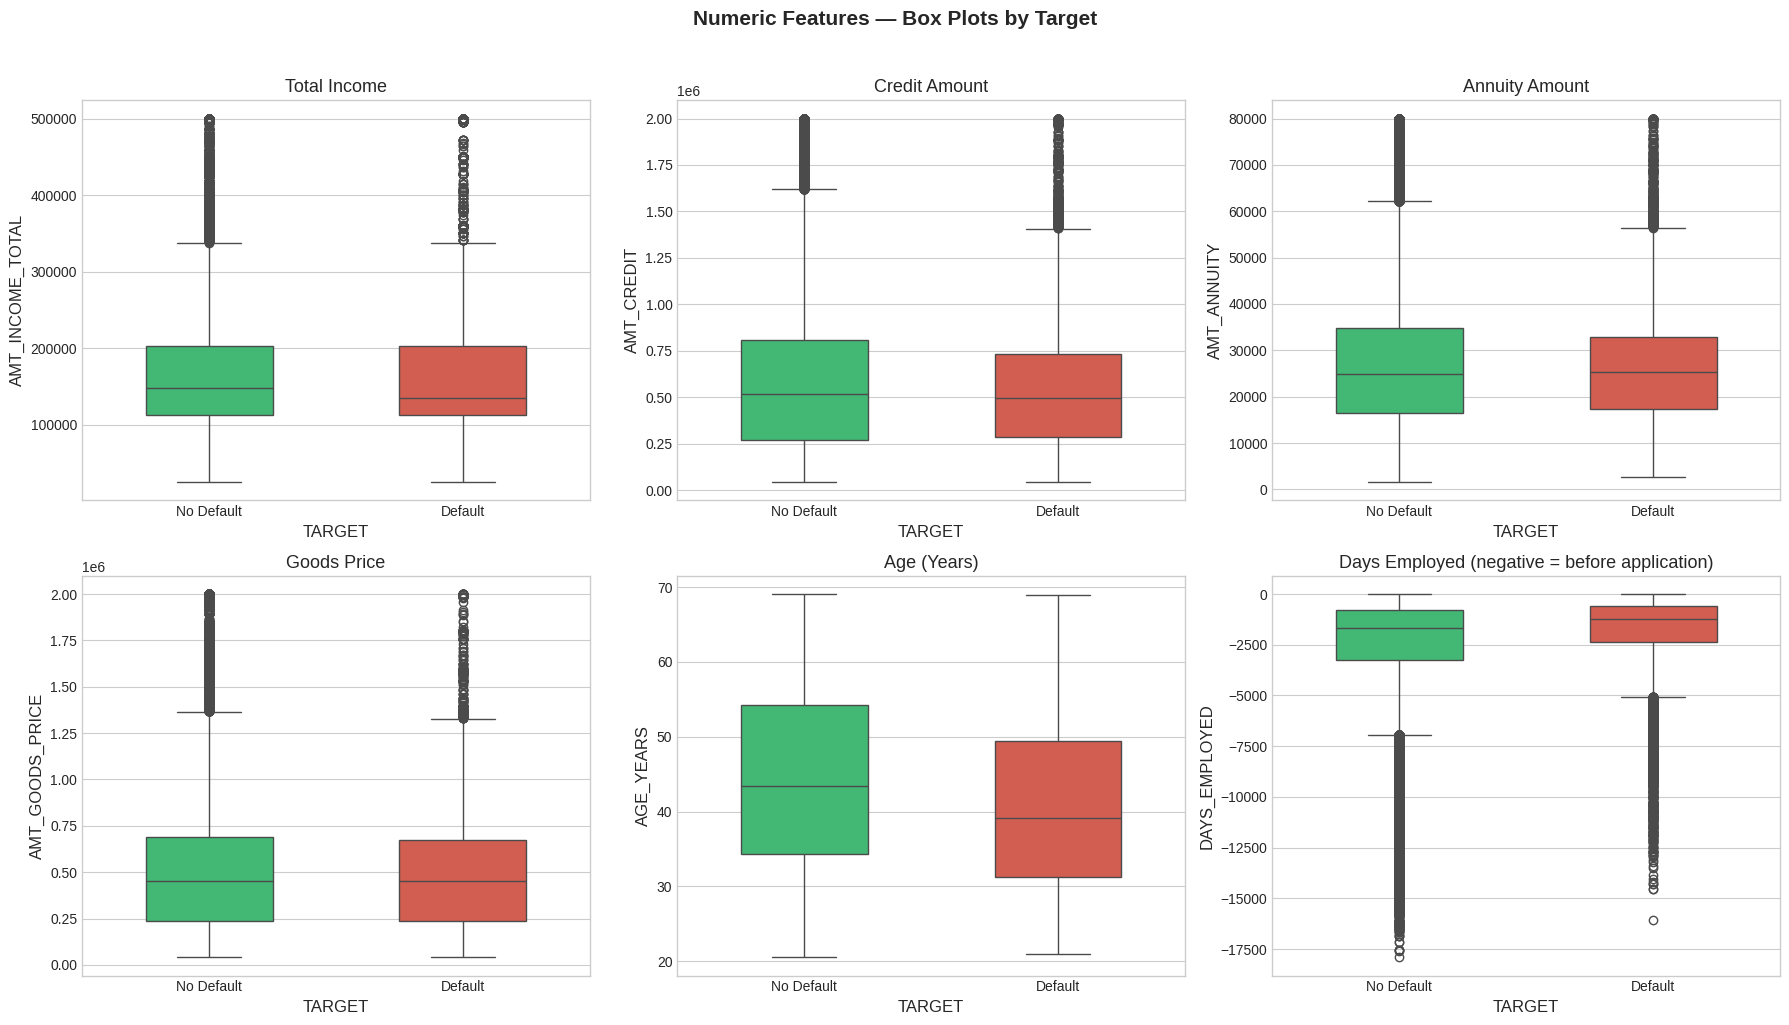

In [6]:
# Box plots split by target for the same features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (feat, config) in enumerate(numeric_features.items()):
    ax = axes[idx]
    plot_data = df[[feat, "TARGET"]].dropna()
    
    if config["clip_upper"] is not None:
        plot_data = plot_data.copy()
        plot_data[feat] = plot_data[feat].clip(upper=config["clip_upper"])
    
    sns.boxplot(data=plot_data, x="TARGET", y=feat, hue="TARGET", ax=ax,
                palette=["#2ecc71", "#e74c3c"], width=0.5, legend=False)
    ax.set_title(config["label"], fontsize=13)
    ax.set_xticklabels(["No Default", "Default"])

fig.suptitle("Numeric Features — Box Plots by Target", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_numeric_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Categorical Features Analysis

In [7]:
cat_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_INCOME_TYPE",
    "ORGANIZATION_TYPE",
]

print("Categorical features — cardinality:\n")
for feat in cat_features:
    n_unique = df[feat].nunique()
    n_missing = df[feat].isna().sum()
    print(f"  {feat:30s}  {n_unique:>4} categories  ({n_missing:,} missing)")

Categorical features — cardinality:

  NAME_CONTRACT_TYPE                 2 categories  (0 missing)
  CODE_GENDER                        2 categories  (4 missing)
  FLAG_OWN_CAR                       2 categories  (0 missing)
  FLAG_OWN_REALTY                    2 categories  (0 missing)
  NAME_EDUCATION_TYPE                5 categories  (0 missing)
  NAME_FAMILY_STATUS                 6 categories  (0 missing)
  NAME_INCOME_TYPE                   8 categories  (0 missing)
  ORGANIZATION_TYPE                 57 categories  (55,374 missing)


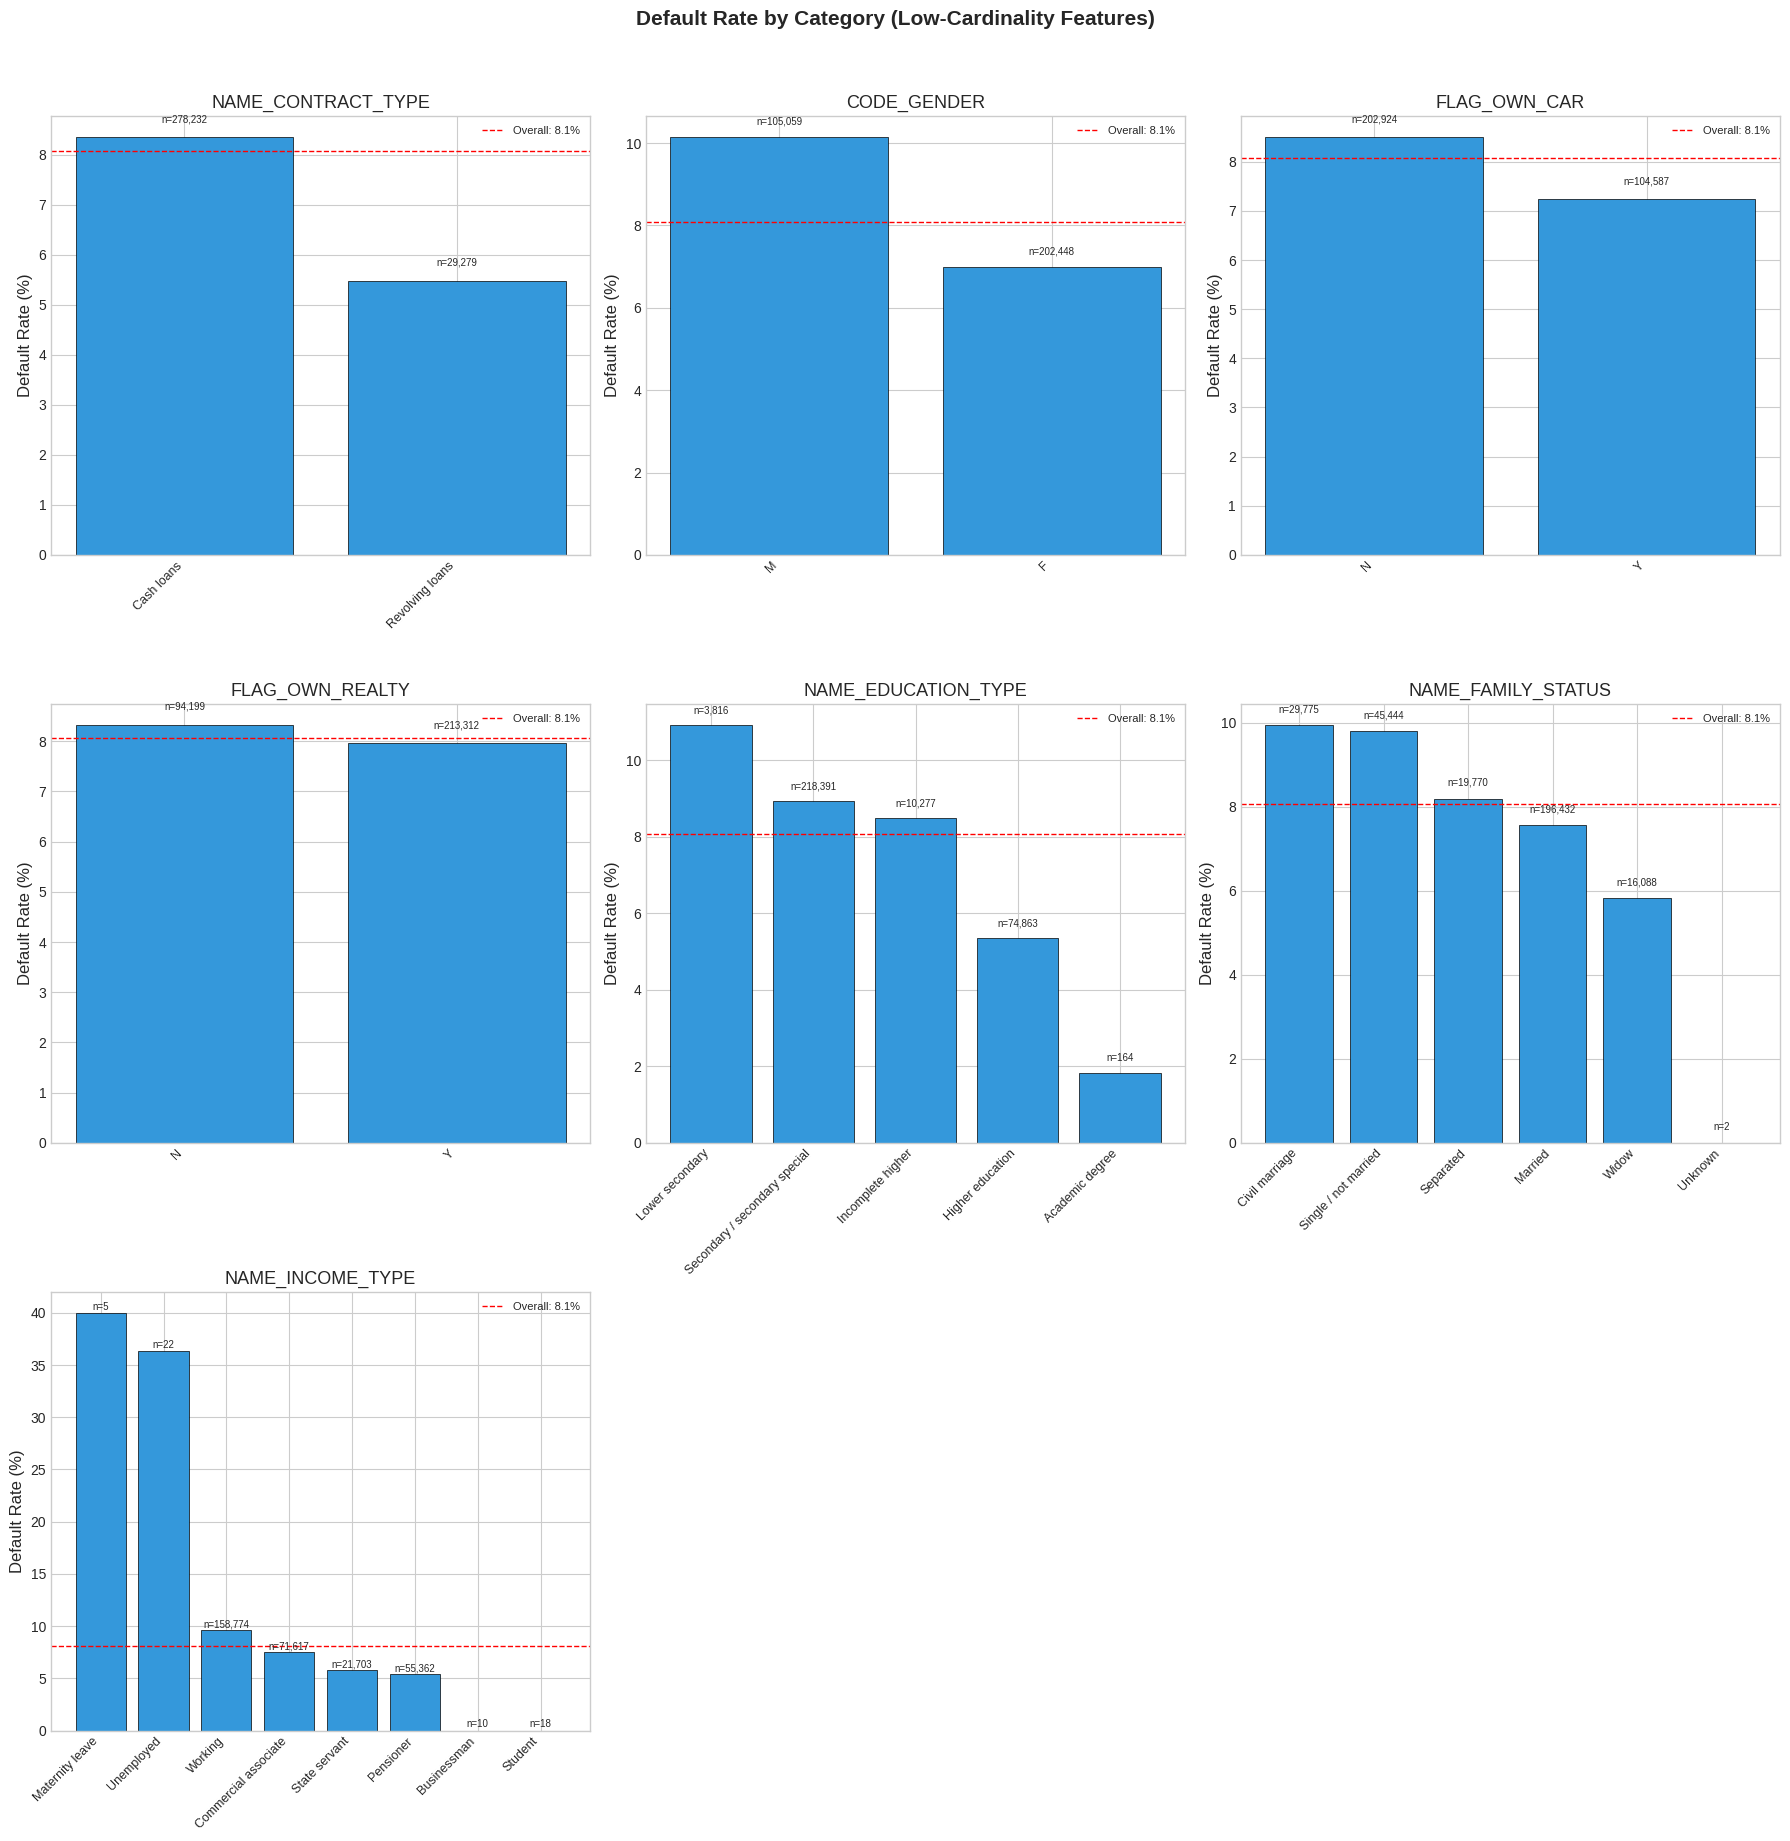

In [8]:
# Default rate per category for low-cardinality features
low_card_features = [f for f in cat_features if df[f].nunique() <= 10]

n_cols = 3
n_rows = -(-len(low_card_features) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for idx, feat in enumerate(low_card_features):
    ax = axes[idx]
    
    # Compute default rate per category
    rates = df.groupby(feat)["TARGET"].agg(["mean", "count"]).reset_index()
    rates.columns = [feat, "default_rate", "count"]
    rates = rates.sort_values("default_rate", ascending=False)
    
    # Bar plot of default rate
    bars = ax.bar(range(len(rates)), rates["default_rate"] * 100,
                  color="#3498db", edgecolor="black", linewidth=0.5)
    ax.set_xticks(range(len(rates)))
    ax.set_xticklabels(rates[feat].astype(str), rotation=45, ha="right", fontsize=9)
    ax.set_title(feat, fontsize=13)
    ax.set_ylabel("Default Rate (%)")
    ax.axhline(y=default_rate * 100, color="red", linestyle="--", linewidth=1, label=f"Overall: {default_rate*100:.1f}%")
    ax.legend(fontsize=8)
    
    # Annotate counts
    for i, (_, row) in enumerate(rates.iterrows()):
        ax.text(i, row["default_rate"] * 100 + 0.3, f"n={row['count']:,.0f}",
                ha="center", fontsize=7, rotation=0)

# Hide unused axes
for idx in range(len(low_card_features), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Default Rate by Category (Low-Cardinality Features)", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_categorical_default_rates.png", dpi=150, bbox_inches="tight")
plt.show()

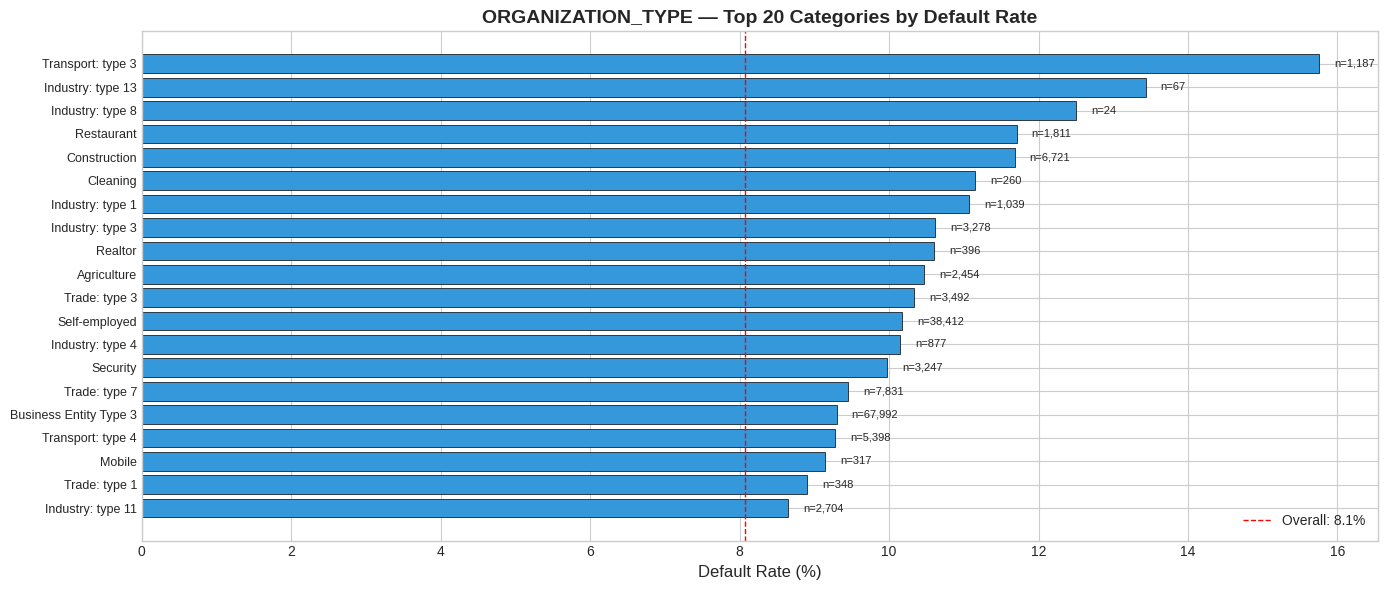

In [9]:
# High-cardinality features: NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, ORGANIZATION_TYPE
high_card_features = [f for f in cat_features if df[f].nunique() > 10]

for feat in high_card_features:
    rates = df.groupby(feat)["TARGET"].agg(["mean", "count"]).reset_index()
    rates.columns = [feat, "default_rate", "count"]
    rates = rates.sort_values("default_rate", ascending=False)
    
    # Show top 20 categories
    top_n = rates.head(20)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(range(len(top_n)), top_n["default_rate"] * 100,
                   color="#3498db", edgecolor="black", linewidth=0.5)
    ax.set_yticks(range(len(top_n)))
    ax.set_yticklabels(top_n[feat].astype(str), fontsize=9)
    ax.set_xlabel("Default Rate (%)")
    ax.set_title(f"{feat} — Top 20 Categories by Default Rate", fontsize=14, fontweight="bold")
    ax.axvline(x=default_rate * 100, color="red", linestyle="--", linewidth=1, label=f"Overall: {default_rate*100:.1f}%")
    ax.legend(fontsize=10)
    ax.invert_yaxis()
    
    # Annotate with counts
    for i, (_, row) in enumerate(top_n.iterrows()):
        ax.text(row["default_rate"] * 100 + 0.2, i, f"n={row['count']:,.0f}", va="center", fontsize=8)
    
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"02_{feat.lower()}_default_rate.png", dpi=150, bbox_inches="tight")
    plt.show()

## 5. Missing Values Analysis

In [10]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "column": missing.index,
    "n_missing": missing.values,
    "pct_missing": missing_pct.values
}).sort_values("pct_missing", ascending=False).reset_index(drop=True)

cols_with_missing = missing_df[missing_df["pct_missing"] > 0]
cols_over_40 = missing_df[missing_df["pct_missing"] > 40]

print(f"Columns with missing values: {len(cols_with_missing)} / {df.shape[1]}")
print(f"Columns with >40% missing:   {len(cols_over_40)}")
print(f"\nColumns with >40% missing:")
for _, row in cols_over_40.iterrows():
    print(f"  {row['column']:45s} {row['pct_missing']:>6.1f}%  ({row['n_missing']:>10,} rows)")

Columns with missing values: 66 / 124
Columns with >40% missing:   49

Columns with >40% missing:
  COMMONAREA_AVG                                  69.9%  (   214,865 rows)
  COMMONAREA_MODE                                 69.9%  (   214,865 rows)
  COMMONAREA_MEDI                                 69.9%  (   214,865 rows)
  NONLIVINGAPARTMENTS_AVG                         69.4%  (   213,514 rows)
  NONLIVINGAPARTMENTS_MODE                        69.4%  (   213,514 rows)
  NONLIVINGAPARTMENTS_MEDI                        69.4%  (   213,514 rows)
  FONDKAPREMONT_MODE                              68.4%  (   210,295 rows)
  LIVINGAPARTMENTS_MEDI                           68.3%  (   210,199 rows)
  LIVINGAPARTMENTS_AVG                            68.3%  (   210,199 rows)
  LIVINGAPARTMENTS_MODE                           68.3%  (   210,199 rows)
  FLOORSMIN_MODE                                  67.8%  (   208,642 rows)
  FLOORSMIN_AVG                                   67.8%  (   208,642 rows)
  

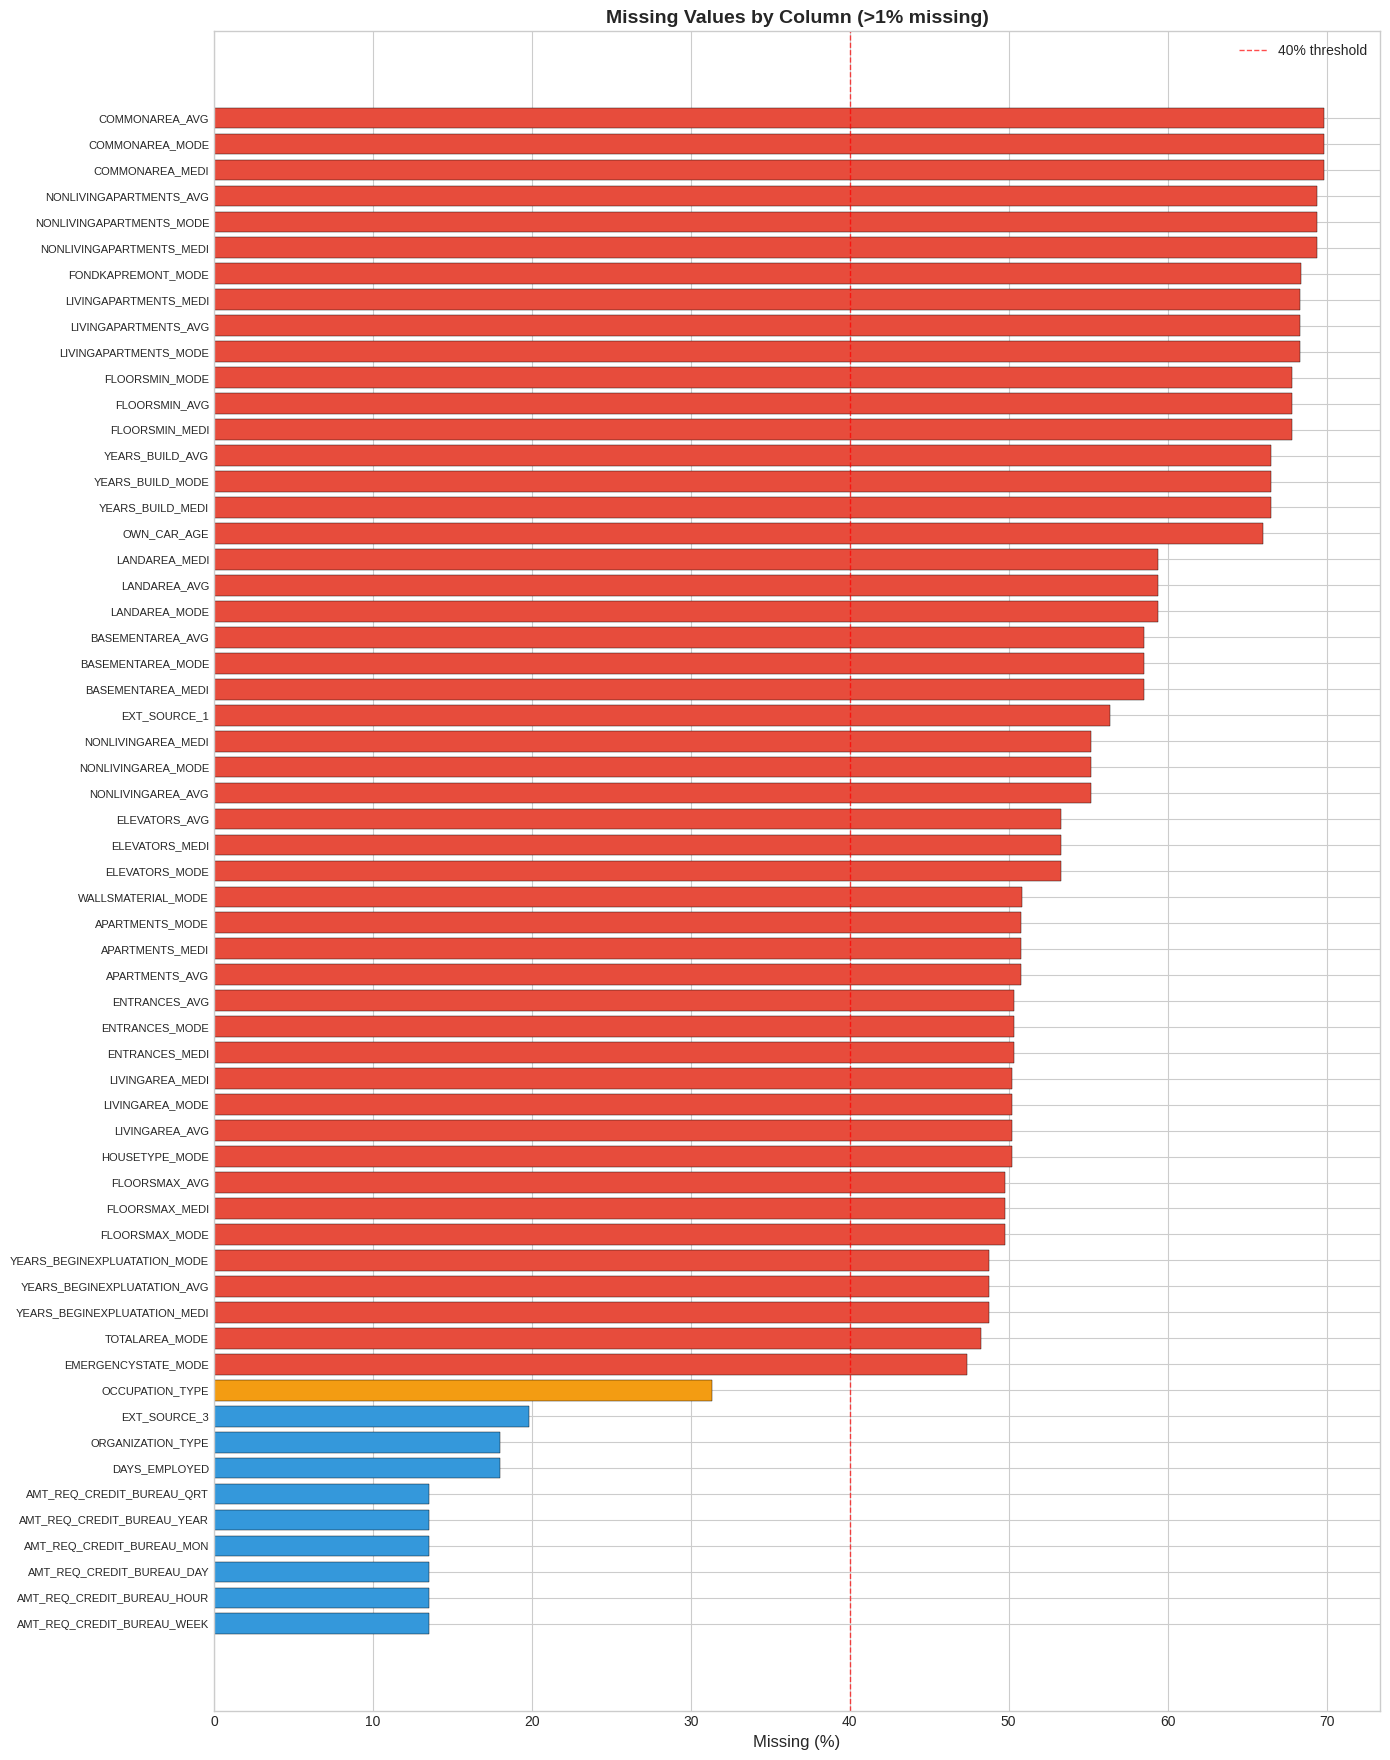

In [11]:
# Bar plot of missing percentages (only columns with >1% missing)
missing_plot = missing_df[missing_df["pct_missing"] > 1].copy()

fig, ax = plt.subplots(figsize=(14, max(6, len(missing_plot) * 0.3)))

colors = ["#e74c3c" if pct > 40 else "#f39c12" if pct > 20 else "#3498db"
          for pct in missing_plot["pct_missing"]]

ax.barh(range(len(missing_plot)), missing_plot["pct_missing"], color=colors,
        edgecolor="black", linewidth=0.3)
ax.set_yticks(range(len(missing_plot)))
ax.set_yticklabels(missing_plot["column"], fontsize=8)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column (>1% missing)", fontsize=14, fontweight="bold")
ax.axvline(x=40, color="red", linestyle="--", linewidth=1, alpha=0.7, label="40% threshold")
ax.legend(fontsize=10)
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Correlation Analysis

In [12]:
# Correlation of numeric features with TARGET
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
correlations = df[numeric_cols].corr()["TARGET"].drop("TARGET").sort_values()

# Top 15 most positively and negatively correlated
top_positive = correlations.tail(15)
top_negative = correlations.head(15)
top_corr = pd.concat([top_negative, top_positive])

print("Top 15 features POSITIVELY correlated with TARGET (default):")
for feat, corr in top_positive.items():
    print(f"  {feat:45s} {corr:>+.4f}")

print(f"\nTop 15 features NEGATIVELY correlated with TARGET (no default):")
for feat, corr in top_negative.items():
    print(f"  {feat:45s} {corr:>+.4f}")

Top 15 features POSITIVELY correlated with TARGET (default):
  DEF_60_CNT_SOCIAL_CIRCLE                      +0.0313
  DEF_30_CNT_SOCIAL_CIRCLE                      +0.0322
  LIVE_CITY_NOT_WORK_CITY                       +0.0325
  OWN_CAR_AGE                                   +0.0376
  DAYS_REGISTRATION                             +0.0420
  FLAG_DOCUMENT_3                               +0.0443
  REG_CITY_NOT_LIVE_CITY                        +0.0444
  FLAG_EMP_PHONE                                +0.0460
  REG_CITY_NOT_WORK_CITY                        +0.0510
  DAYS_ID_PUBLISH                               +0.0515
  DAYS_LAST_PHONE_CHANGE                        +0.0552
  REGION_RATING_CLIENT                          +0.0589
  REGION_RATING_CLIENT_W_CITY                   +0.0609
  DAYS_EMPLOYED                                 +0.0750
  DAYS_BIRTH                                    +0.0782

Top 15 features NEGATIVELY correlated with TARGET (no default):
  EXT_SOURCE_3                    

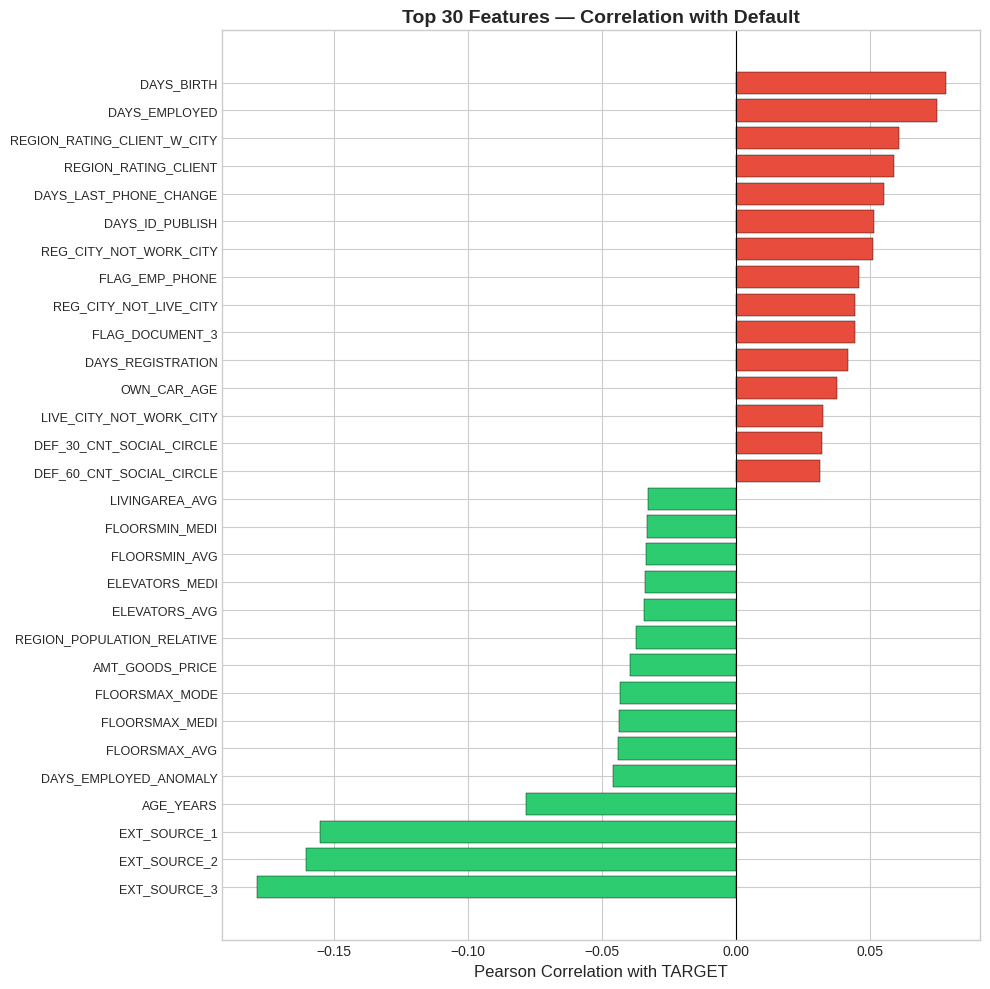

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

colors = ["#e74c3c" if v > 0 else "#2ecc71" for v in top_corr.values]

ax.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor="black", linewidth=0.3)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=9)
ax.set_xlabel("Pearson Correlation with TARGET")
ax.set_title("Top 30 Features — Correlation with Default", fontsize=14, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_correlation_with_target.png", dpi=150, bbox_inches="tight")
plt.show()

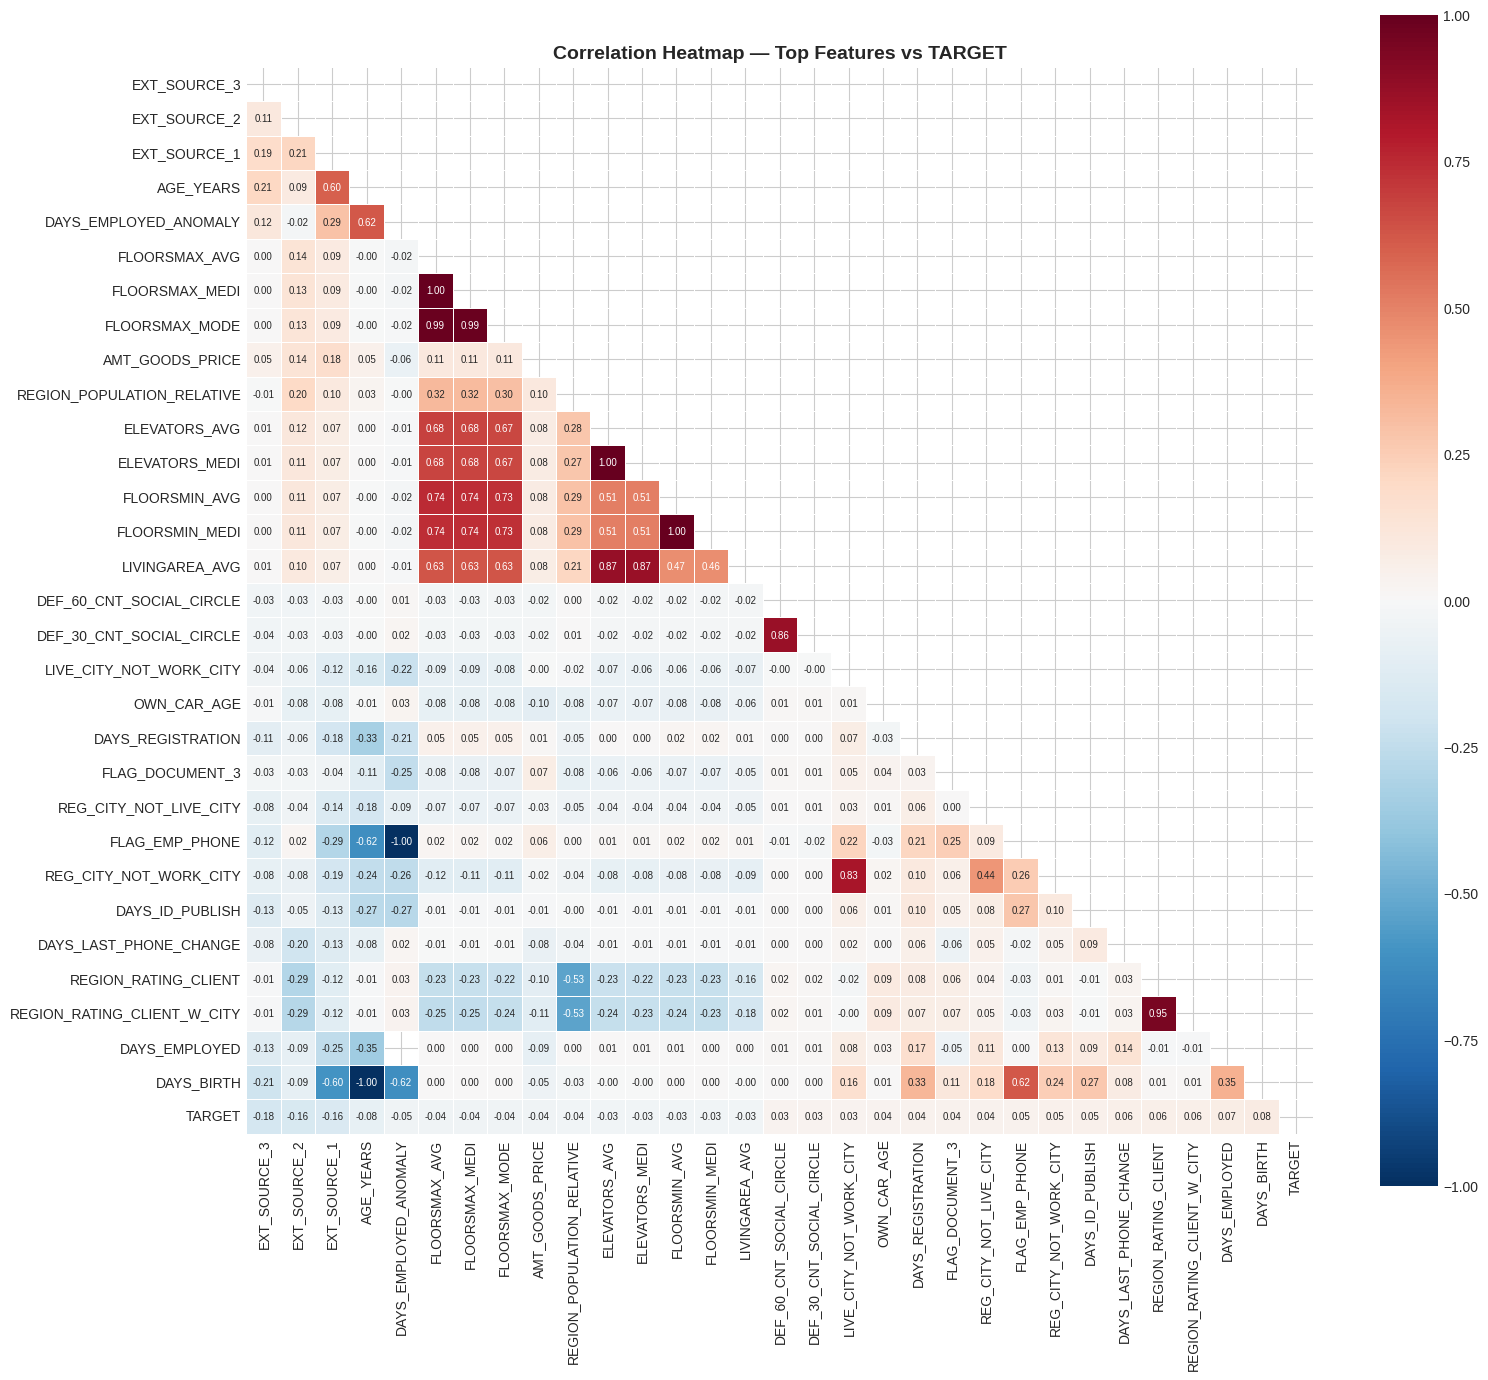

In [14]:
# Correlation heatmap of top correlated features + TARGET
top_features = list(top_corr.index) + ["TARGET"]
# Keep only features that exist (some may have been dropped)
top_features = [f for f in top_features if f in df.columns]

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={"size": 7}, linewidths=0.5)
ax.set_title("Correlation Heatmap — Top Features vs TARGET", fontsize=14, fontweight="bold")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Bureau Data Quick Look

In [15]:
bureau = pd.read_parquet(PROCESSED_DIR / "bureau.parquet")

print(f"Bureau table shape: {bureau.shape[0]:,} rows × {bureau.shape[1]} columns")
print(f"Unique clients:     {bureau['SK_ID_CURR'].nunique():,}")
print(f"Unique bureau IDs:  {bureau['SK_ID_BUREAU'].nunique():,}")
print(f"\nColumns: {list(bureau.columns)}")

bureau.head(3)

Bureau table shape: 1,716,428 rows × 17 columns
Unique clients:     305,811
Unique bureau IDs:  1,716,428

Columns: ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN


Bureau records per client — statistics:
count    305811.0
mean          5.6
std           4.4
min           1.0
25%           2.0
50%           4.0
75%           8.0
max         116.0
dtype: float64


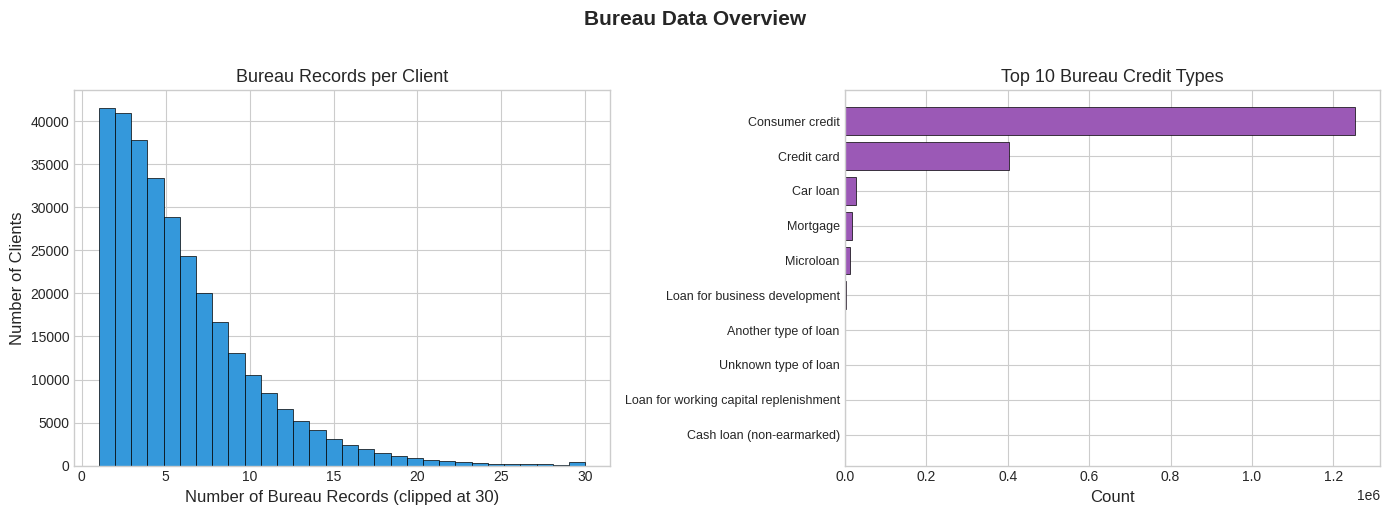

In [16]:
# Number of bureau records per client
records_per_client = bureau.groupby("SK_ID_CURR").size()

print("Bureau records per client — statistics:")
print(records_per_client.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of number of bureau records per client
axes[0].hist(records_per_client.clip(upper=30), bins=30, color="#3498db",
             edgecolor="black", linewidth=0.5)
axes[0].set_title("Bureau Records per Client", fontsize=13)
axes[0].set_xlabel("Number of Bureau Records (clipped at 30)")
axes[0].set_ylabel("Number of Clients")

# Credit types distribution
if "CREDIT_TYPE" in bureau.columns:
    credit_type_col = "CREDIT_TYPE"
elif "credit_type" in bureau.columns:
    credit_type_col = "credit_type"
else:
    credit_type_col = None

if credit_type_col:
    credit_types = bureau[credit_type_col].value_counts().head(10)
    axes[1].barh(range(len(credit_types)), credit_types.values, color="#9b59b6",
                 edgecolor="black", linewidth=0.5)
    axes[1].set_yticks(range(len(credit_types)))
    axes[1].set_yticklabels(credit_types.index, fontsize=9)
    axes[1].set_xlabel("Count")
    axes[1].set_title("Top 10 Bureau Credit Types", fontsize=13)
    axes[1].invert_yaxis()
else:
    # Fallback: show CREDIT_ACTIVE distribution if available
    active_col = [c for c in bureau.columns if "ACTIVE" in c.upper()]
    if active_col:
        credit_active = bureau[active_col[0]].value_counts()
        axes[1].barh(range(len(credit_active)), credit_active.values, color="#9b59b6",
                     edgecolor="black", linewidth=0.5)
        axes[1].set_yticks(range(len(credit_active)))
        axes[1].set_yticklabels(credit_active.index, fontsize=9)
        axes[1].set_xlabel("Count")
        axes[1].set_title("Bureau Credit Status", fontsize=13)
        axes[1].invert_yaxis()

fig.suptitle("Bureau Data Overview", fontsize=15, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_bureau_overview.png", dpi=150, bbox_inches="tight")
plt.show()

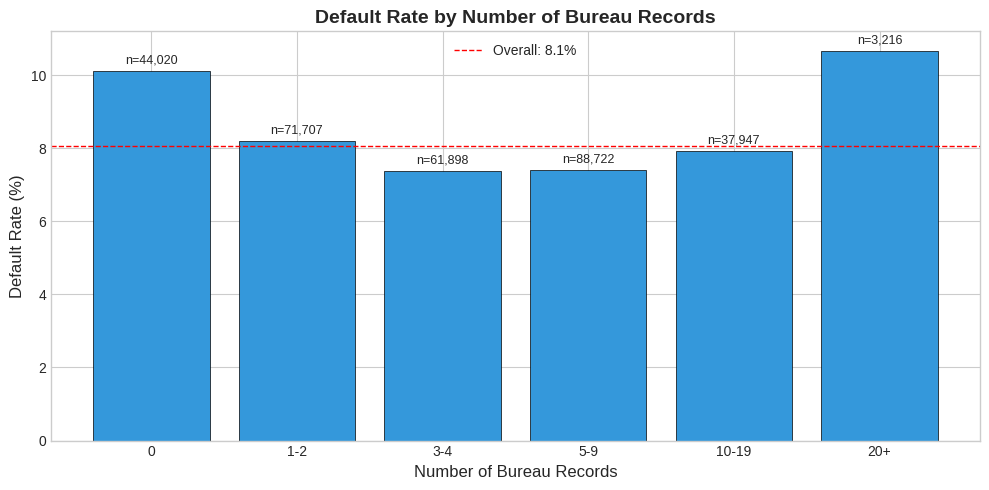

In [17]:
# Merge bureau record counts with target and check relationship
bureau_counts = bureau.groupby("SK_ID_CURR").size().reset_index(name="n_bureau_records")
df_with_bureau = df[["SK_ID_CURR", "TARGET"]].merge(bureau_counts, on="SK_ID_CURR", how="left")
df_with_bureau["n_bureau_records"] = df_with_bureau["n_bureau_records"].fillna(0).astype(int)

# Bin the bureau record counts
bins = [0, 1, 3, 5, 10, 20, 100]
labels = ["0", "1-2", "3-4", "5-9", "10-19", "20+"]
df_with_bureau["bureau_bin"] = pd.cut(df_with_bureau["n_bureau_records"], bins=bins,
                                       labels=labels, right=False)

bureau_default = df_with_bureau.groupby("bureau_bin")["TARGET"].agg(["mean", "count"]).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(bureau_default)), bureau_default["mean"] * 100,
       color="#3498db", edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(bureau_default)))
ax.set_xticklabels(bureau_default["bureau_bin"])
ax.set_xlabel("Number of Bureau Records")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Number of Bureau Records", fontsize=14, fontweight="bold")
ax.axhline(y=default_rate * 100, color="red", linestyle="--", linewidth=1,
           label=f"Overall: {default_rate*100:.1f}%")
ax.legend()

for i, row in bureau_default.iterrows():
    ax.text(i, row["mean"] * 100 + 0.2, f"n={row['count']:,.0f}",
            ha="center", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_bureau_default_rate.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

### Key Findings

**1. Target Imbalance**
- Default rate is 8.07% (1:11 ratio) — significant class imbalance
- Will require stratified sampling and metrics like AUC-ROC and PR-AUC (not accuracy)

**2. Numeric Features**
- **AGE_YEARS**: Younger applicants have higher default rates; the distributions clearly separate by target
- **DAYS_EMPLOYED**: Shorter employment history is associated with higher default risk
- **AMT_INCOME_TOTAL**: Heavy right skew with extreme outliers; modest separation by target
- **AMT_CREDIT / AMT_ANNUITY / AMT_GOODS_PRICE**: Amount features show subtle differences by target — ratios (e.g., annuity/credit, credit/income) may be more informative

**3. Categorical Features**
- **NAME_INCOME_TYPE**: Unemployed and maternity-leave applicants have the highest default rates
- **NAME_EDUCATION_TYPE**: Lower education is associated with higher default risk
- **NAME_CONTRACT_TYPE**: Revolving loans have higher default rates than cash loans
- **ORGANIZATION_TYPE**: Significant variation across organization types — useful for encoding

**4. Missing Values**
- Several columns have >40% missing data (mostly external source and housing-related features)
- Missing patterns may themselves be informative — consider "is_missing" indicator features

**5. Correlations**
- Individual feature correlations with TARGET are weak (|r| < 0.10 for most)
- Top positive correlations: external source scores, age, and flag variables
- This suggests that engineered features and non-linear models will be important

**6. Bureau Data**
- ~86% of training clients have bureau records
- Median of ~7 bureau records per client; heavy right tail
- Number of bureau records relates to default risk — aggregated bureau features will be valuable

**Next:** NB03 — Feature Engineering (aggregations, domain features, ratio features)